# Playground — poke your GPT-2 while it trains

Everything here runs on **CPU** (numpy), so it can't disturb the GPU training run.
Checkpoints are **snapshotted before loading** because the trainer rewrites
`ckpt.npz` every 500 iters and a mid-write read would be corrupt.

Kernel: **Python 3.12 (rumik-gpt2)** (or launch jupyter from `.venv` and use the default).

Note: generation is autoregressive with no KV cache, on CPU — expect ~0.1–0.3s
per token on the OWT model. Keep prompts non-empty.

In [1]:
import csv, os, pickle, shutil, sys, time
sys.path.insert(0, os.path.abspath(".."))   # repo root
import numpy as np
import matplotlib.pyplot as plt
import tiktoken
import checkpoint
from model import GPT, GPTConfig

def load_model(ckpt_path):
    """Snapshot then load — the training run rewrites the original file."""
    snap = f"{ckpt_path}.{int(time.time())}.snap"
    shutil.copy(ckpt_path, snap)
    cfg, arrays, it, _ = checkpoint.load(snap)
    m = GPT(GPTConfig(**cfg["model"]))
    for p, a in zip(m.parameters(), arrays):
        p.data[...] = a
    print(f"loaded {ckpt_path} @ iter {it}")
    return m, cfg, it

## 1. The Shakespeare model (finished training — always coherent-ish)

In [2]:
m_shk, cfg_shk, _ = load_model("../out/shakespeare_char/ckpt.npz")
with open("../" + cfg_shk["data_dir"] + "/meta.pkl", "rb") as f:
    meta = pickle.load(f)

def talk_shakespeare(prompt="ROMEO:", n=300, temp=0.8):
    idx = np.array([[meta["stoi"][c] for c in prompt]])
    out = m_shk.generate(idx, n, temperature=temp, top_k=40, seed=None or 1337)
    print("".join(meta["itos"][i] for i in out[0].tolist()))

talk_shakespeare("ROMEO:")

loaded ../out/shakespeare_char/ckpt.npz @ iter 3000
ROMEO:
By the kname and tend tlib, that you content
Disposing that the hearth of please,
That I may be words so end him to itself?
O, and you have give his the brow of them worm
Of our obstrocks thems consulk'd of fair his pardoned
To me head, death years danged years and his death,
Or neight law appardic


## 2. The OpenWebText model (LIVE — re-run the cell below anytime to grab the
latest checkpoint and watch it get smarter overnight)

In [3]:
m_owt, cfg_owt, it = load_model("../out/owt_gpu/ckpt.npz")
enc = tiktoken.get_encoding("gpt2")

def talk(prompt, n=60, temp=0.8, top_k=100, seed=1337):
    idx = np.array([enc.encode_ordinary(prompt)])
    out = m_owt.generate(idx, n, temperature=temp, top_k=top_k, seed=seed)
    print(enc.decode([int(t) for t in out[0]]))

talk("The meaning of life is")

loaded ../out/owt_gpu/ckpt.npz @ iter 15000
The meaning of life is often the primary component of a person's life that, in turn, is the life-threatening, physical life, all those things, was born out of the flesh and flesh of a world. It is also the life of a man. He is not living in a world. He is a father


## 3. X-ray view: what does it think comes next?
The top-10 next-token distribution — the honest window into what the model
actually knows (sampling can hide or flatter it).

In [4]:
def next_token_table(prompt, k=10):
    idx = np.array([enc.encode_ordinary(prompt)])
    logits, _ = m_owt(idx)
    lg = logits.data[0, -1]
    p = np.exp(lg - lg.max()); p /= p.sum()
    print(f"prompt: {prompt!r}")
    for i in np.argsort(-p)[:k]:
        print(f"  {p[i]:6.3f}  {enc.decode([int(i)])!r}")

next_token_table("The capital of France is")
next_token_table("She opened the door and")

prompt: 'The capital of France is'
   0.077  ' the'
   0.059  ' a'
   0.043  ' expected'
   0.034  ' in'
   0.022  ' now'
   0.018  ' also'
   0.018  ' set'
   0.018  ' being'
   0.017  ' to'
   0.016  ' not'
prompt: 'She opened the door and'
   0.060  ' opened'
   0.049  ' said'
   0.035  ' was'
   0.026  ' told'
   0.026  ' saw'
   0.026  ' walked'
   0.023  ' started'
   0.023  ' began'
   0.022  ' asked'
   0.020  ' took'


## 4. Live loss curve of the overnight run (re-run anytime)

latest: iter 14880, train loss 4.183, ~244M tokens seen, ppl 65.6


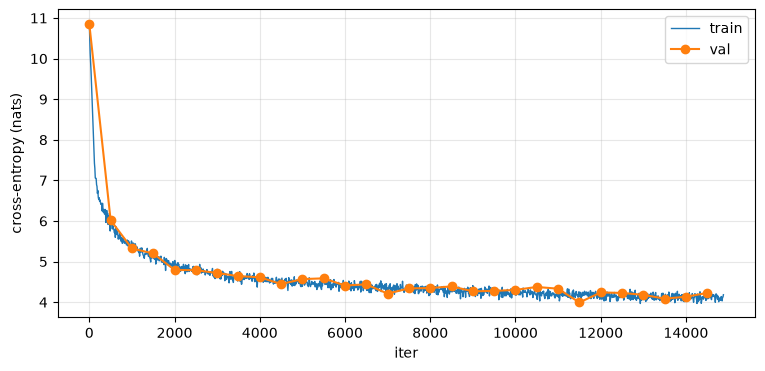

In [5]:
it_, tr, vit, vl = [], [], [], []
with open("../out/owt_gpu/log.csv") as f:
    for row in csv.DictReader(f):
        it_.append(int(row["iter"])); tr.append(float(row["train_loss"]))
        if row["val_loss"]:
            vit.append(int(row["iter"])); vl.append(float(row["val_loss"]))
plt.figure(figsize=(9, 4))
plt.plot(it_, tr, lw=1, label="train")
if vit: plt.plot(vit, vl, "o-", label="val")
plt.xlabel("iter"); plt.ylabel("cross-entropy (nats)"); plt.legend(); plt.grid(alpha=.3)
print(f"latest: iter {it_[-1]}, train loss {tr[-1]:.3f}, "
      f"~{16384 * it_[-1] / 1e6:.0f}M tokens seen, ppl {np.exp(tr[-1]):.1f}")

## Terminal alternative (non-headless, no notebook)
```powershell
cd C:\\Users\\Soumyadip\\Documents\\Claude\\Interview\\rumik
Copy-Item out\\owt_gpu\\ckpt.npz out\\owt_gpu\\ckpt_snap.npz
.venv\\Scripts\\python.exe sample.py out\\owt_gpu\\ckpt_snap.npz --prompt "Once upon a time" --num-tokens 80
```